# Approach 1 — guided design with the dual surrogate + oracle

Property-guided FP design wired to the models from `surrogate_model_design_dual.ipynb`:

- **Surrogate** = `dual_surrogate_net.pt` (**cnn-max**) — *guides* refinement.
- **Oracle** = `dual_oracle_net.pt` (**cnn-max**, trained on the oracle split) — independent *evaluator*.

Both are CNNs trained with a **cosine-similarity** loss; each predicts **PCA coefficients** that are reconstructed
and **peak-normalized** to a spectrum via its saved PCA basis. Guided generation scores candidates by **cosine
similarity** to the target spectrum (not MSE). Using the dual labels (`dual_splits.csv`) we design toward
**in-sample** (surrogate-seen) and **OOD** (surrogate-unseen) targets, judged by the oracle, sweeping the guidance
strength **λ ∈ {5, 15}**.

## 0. Setup + data + dual labels

In [1]:
import csv, os, numpy as np, torch, joblib
import arcadia_pycolor as apc, fp_models as fpm
try:
    import matplotlib.pyplot as plt; HAVE_PLT=True; apc.mpl.setup()
except Exception: HAVE_PLT=False
TD="training_data"; DS=os.path.join("..","fpbase-extractor","processed_data","ESM-spectrum")
dev=torch.device("mps") if (getattr(torch.backends,"mps",None) and torch.backends.mps.is_available()) \
    else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
rows=list(csv.DictReader(open(os.path.join(TD,"split_assignments.csv")))); N=len(rows)
Y=np.load(os.path.join(TD,"spectra.npy")).astype(np.float32); grid=np.load(os.path.join(DS,"grid_nm.npy")); G=len(grid)
EMM=np.array([float(r["em_max"]) for r in rows]); EXM=np.array([float(r["ex_max"]) for r in rows])
seqs=[None]*N; h=None
for line in open(os.path.join(TD,"sequences.fasta")):
    line=line.strip()
    if line.startswith(">"): h=int(line[1:].split("|")[0])
    elif line: seqs[h]=line
dual=list(csv.DictReader(open(os.path.join(TD,"dual_splits.csv"))))
Srole=np.array([d["surrogate_role"] for d in dual]); Orole=np.array([d["oracle_role"] for d in dual])
print("device",dev,"| N",N,"| surrogate roles",{b:int((Srole==b).sum()) for b in('train','val','test')})

device mps | N 453 | surrogate roles {'train': 317, 'val': 68, 'test': 68}


## 1. Load dual models (+ PCA bases) and wire spectrum predictors

In [2]:
surrogate_net, s_meta = fpm.load_model(os.path.join("trained_models","dual_surrogate_net.pt"), dev)
oracle_net,    o_meta = fpm.load_model(os.path.join("trained_models","dual_oracle_net.pt"), dev)
surr_pca = joblib.load(os.path.join("trained_models","dual_surrogate_pca.joblib"))
orac_pca = joblib.load(os.path.join("trained_models","dual_oracle_pca.joblib"))
print(f"surrogate: {s_meta['sid']} (out={s_meta['out']} PCA coeffs) | val MSE {s_meta['metrics']['val']['mse']:.4f}")
print(f"oracle:    {o_meta['sid']} (out={o_meta['out']} PCA coeffs) | val MSE {o_meta['metrics']['val']['mse']:.4f}")

g_spectrum      = fpm.pca_spectrum_fn(surrogate_net, surr_pca, dev)   # GUIDANCE (PCA recon + peak-normalized spectrum)
oracle_spectrum = fpm.pca_spectrum_fn(oracle_net,   orac_pca, dev)    # EVALUATION (PCA recon + peak-normalized spectrum)

esm_model, alphabet, bc = fpm.get_esm(dev)
AA_MASK = torch.zeros(len(alphabet.all_toks), dtype=torch.bool)
for a in "ACDEFGHIKLMNPQRSTVWY": AA_MASK[alphabet.get_idx(a)] = True
AA_MASK = AA_MASK.to(dev)
SPECIAL = {alphabet.cls_idx, alphabet.eos_idx, alphabet.padding_idx, alphabet.mask_idx}

surrogate: cnn-max (out=32 PCA coeffs) | val MSE 0.0326
oracle:    cnn-max (out=32 PCA coeffs) | val MSE 0.0325


## 2. Pseudo-perplexity (naturalness)

In [3]:
@torch.no_grad()
def pseudo_perplexity(seq, batch_size=32):
    _,_,base=bc([("s",seq.strip().upper())]); base=base[0].to(dev)
    res=[i for i,t in enumerate(base.tolist()) if t not in SPECIAL]; tot=0.0
    for s in range(0,len(res),batch_size):
        ch=res[s:s+batch_size]; bt=base.unsqueeze(0).repeat(len(ch),1).clone()
        for r,p in enumerate(ch): bt[r,p]=alphabet.mask_idx
        lp=torch.log_softmax(esm_model(bt)["logits"],dim=-1)
        for r,p in enumerate(ch): tot+=float(lp[r,p,base[p]])
    n=len(res); return tot, float(np.exp(-tot/n))

loaded cached pseudo-perplexities (fp_designs/ppl_id_ood.csv)
ID  median 15.90 (n=40) | OOD median 15.67 (n=40) | Mann-Whitney p=0.37


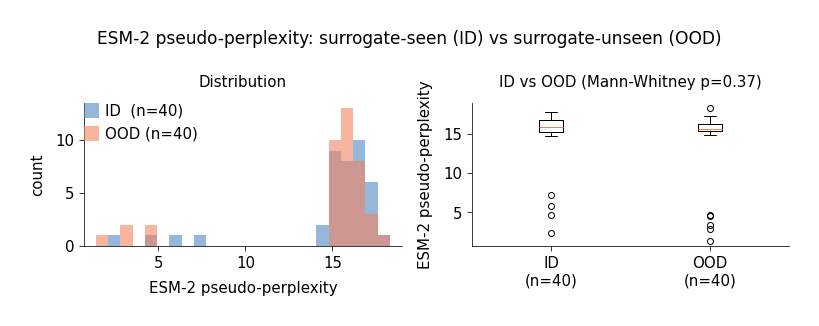

In [4]:
# Pseudo-perplexity distribution: ID (surrogate-seen, Srole==train) vs OOD (surrogate-unseen, Srole==test)
from scipy.stats import mannwhitneyu
PPL_PER_GROUP=40          # sample size per group (None = all; all is slow); results cached to fp_designs/
ppl_cache=os.path.join("fp_designs","ppl_id_ood.csv")
if os.path.exists(ppl_cache):
    rec=list(csv.DictReader(open(ppl_cache)))
    groups={g:np.array([float(r["ppl"]) for r in rec if r["group"]==g]) for g in ("ID","OOD")}
    print(f"loaded cached pseudo-perplexities ({ppl_cache})")
else:
    rng_ppl=np.random.default_rng(0)
    def _sample(role):
        idx=np.where(Srole==role)[0]
        if PPL_PER_GROUP and len(idx)>PPL_PER_GROUP: idx=np.sort(rng_ppl.choice(idx,PPL_PER_GROUP,replace=False))
        return idx
    groups={}; out_rows=[]
    for g,role in [("ID","train"),("OOD","test")]:
        vals=[]
        for i in _sample(role):
            _,p=pseudo_perplexity(seqs[i]); vals.append(p); out_rows.append((g,int(i),rows[i]["name"],f"{p:.4f}"))
        groups[g]=np.array(vals); print(f"{g}: n={len(vals)} median {np.median(vals):.2f} mean {np.mean(vals):.2f}")
    os.makedirs("fp_designs",exist_ok=True)
    with open(ppl_cache,"w",newline="") as fh:
        w=csv.writer(fh); w.writerow(["group","idx","name","ppl"]); [w.writerow(r) for r in out_rows]
    print(f"saved -> {ppl_cache}")

p_mwu=mannwhitneyu(groups["OOD"],groups["ID"],alternative="two-sided").pvalue
print(f"ID  median {np.median(groups['ID']):.2f} (n={len(groups['ID'])}) | "
      f"OOD median {np.median(groups['OOD']):.2f} (n={len(groups['OOD'])}) | Mann-Whitney p={p_mwu:.2g}")
if HAVE_PLT:
    fig,ax=plt.subplots(1,2,figsize=(11,4))
    lo=min(groups['ID'].min(),groups['OOD'].min()); hi=max(groups['ID'].max(),groups['OOD'].max())
    bins=np.linspace(lo,hi,25)
    ax[0].hist(groups['ID'], bins=bins, alpha=0.6, color=apc.aegean, label=f"ID  (n={len(groups['ID'])})")
    ax[0].hist(groups['OOD'],bins=bins, alpha=0.6, color=apc.amber,  label=f"OOD (n={len(groups['OOD'])})")
    ax[0].set_xlabel("ESM-2 pseudo-perplexity"); ax[0].set_ylabel("count"); ax[0].legend(); ax[0].set_title("Distribution")
    ax[1].boxplot([groups['ID'],groups['OOD']], tick_labels=[f"ID\n(n={len(groups['ID'])})", f"OOD\n(n={len(groups['OOD'])})"])
    ax[1].set_ylabel("ESM-2 pseudo-perplexity"); ax[1].set_title(f"ID vs OOD (Mann-Whitney p={p_mwu:.2g})")
    plt.suptitle("ESM-2 pseudo-perplexity: surrogate-seen (ID) vs surrogate-unseen (OOD)")
    plt.tight_layout(); plt.show()

## 3. Guided refinement (surrogate guides, oracle evaluates)

In [5]:
def to_tokens(seq): _,_,t=bc([("q",seq.strip().upper())]); return t.to(dev)
def tokens_to_seq(t1d): return "".join(alphabet.get_tok(int(x)) for x in t1d if int(x) not in SPECIAL)

def cos_sim_vec(P, t):
    """Mean per-half (ex|em) cosine similarity between spectra P (B,2G) and a target t (2G,). Higher = better."""
    def cs(a,b): return (a*b).sum(-1)/(a.norm(dim=-1)*b.norm(dim=-1)+1e-8)
    return 0.5*(cs(P[:,:G], t[:G]) + cs(P[:,G:], t[G:]))

@torch.no_grad()
def guided_refine(seq, target, n_sweeps=1, k=6, lam=5.0, temperature=0.0, editable=None, eval_fn=None, verbose=True):
    toks=to_tokens(seq)
    res=[i for i,t in enumerate(toks[0].tolist()) if t not in SPECIAL]
    if editable is not None: res=[res[j] for j in editable]
    trace=[]
    for sweep in range(n_sweeps):
        for pos in res:
            toks[0,pos]=alphabet.mask_idx
            lg=esm_model(toks)["logits"][0,pos].masked_fill(~AA_MASK,float("-inf"))
            logp=torch.log_softmax(lg,-1); topv,topi=torch.topk(logp,k)
            cand=[]
            for idx in topi.tolist(): toks[0,pos]=idx; cand.append(tokens_to_seq(toks[0]))
            sim=cos_sim_vec(g_spectrum(cand), target)                              # surrogate guidance: cosine similarity
            lpz=(topv-topv.mean())/(topv.std()+1e-6); sz=(sim-sim.mean())/(sim.std()+1e-6)
            scores=lpz+lam*sz                                                       # reward naturalness + spectral similarity
            ch=(torch.multinomial(torch.softmax(scores/temperature,-1),1).item() if temperature>0 else int(torch.argmax(scores)))
            toks[0,pos]=int(topi[ch].item())
        cur=tokens_to_seq(toks[0])
        ev=(eval_fn(cur)[0] if eval_fn is not None else g_spectrum(cur)[0])         # oracle evaluation
        sim_ev=float(cos_sim_vec(ev.unsqueeze(0), target)[0]); trace.append(sim_ev)
        if verbose: print(f"  sweep {sweep}: oracle cosine {sim_ev:.4f}")
    return tokens_to_seq(toks[0]), trace

## 4. Sequence-similar scaffold→target pairs (ID & OOD) — iterative windowed design

For each group we auto-pick a **sequence-similar** scaffold→target pair (highest 4-mer similarity with an emission gap ≥ `EM_GAP_MIN` nm and identity ≤ `IDENT_MAX`, so it is a real but tractable design): the **target** is surrogate-seen for **in-sample** (`Srole==train`) and surrogate-unseen for **OOD** (`Srole==test`). From the scaffold we run **windowed** guided refinement for `N_ROUNDS` constant-λ rounds, then `EXTRA_ROUNDS` more rounds that **ramp λ by `LAM_STEP` each round** (continuing the same design), for start-λ ∈ {20, 30}. Per-round history (incl. `lam_used`) → `fp_designs/designs_history.csv`; final design per (group, start-λ) → `fp_designs/designs.csv`.

In [6]:
REGENERATE=True       # set False to reuse fp_designs/designs_history.csv
N_ROUNDS=5; EXTRA_ROUNDS=5; LAM_STEP=2          # 5 const-lambda rounds, then 5 more ramping lambda +2/round
WINDOW=40; K_TOP=6; LAMBDAS=[20,30]; EM_GAP_MIN=20; EM_GAP_MAX=80; IDENT_MAX=0.98
hist_path=os.path.join("fp_designs","designs_history.csv"); dpath=os.path.join("fp_designs","designs.csv")

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity as _cossim
import biotite.sequence as _bseq, biotite.sequence.align as _balign
_MAT=_balign.SubstitutionMatrix.std_protein_matrix()
def seq_identity(a,b):
    aln=_balign.align_optimal(_bseq.ProteinSequence(a),_bseq.ProteinSequence(b),_MAT,gap_penalty=(-10,-1))[0]
    return float(_balign.get_sequence_identity(aln))
def find_pair(role):                                              # most 4-mer-similar pair: real spectral gap, but not a near-duplicate
    idx=np.where(Srole==role)[0]
    X=CountVectorizer(analyzer="char",ngram_range=(4,4)).fit_transform([seqs[i] for i in idx])
    S=_cossim(X)
    cand=[(float(S[a,b]),int(idx[a]),int(idx[b])) for a in range(len(idx)) for b in range(a+1,len(idx))
          if EM_GAP_MIN<=abs(EMM[idx[a]]-EMM[idx[b]])<=EM_GAP_MAX]
    cand.sort(reverse=True)                                        # rank by 4-mer similarity (cheap)
    for _,i,j in cand:                                             # accept most-similar pair below the identity cap
        if seqs[i]!=seqs[j] and seq_identity(seqs[i],seqs[j])<=IDENT_MAX: break
    return (i,j) if EMM[i]<=EMM[j] else (j,i)                      # scaffold=bluer, target=redder

if REGENERATE or not os.path.exists(hist_path):
    pairs={"in-sample":find_pair("train"), "OOD":find_pair("test")}
    hist=[]
    def rec(label,lam,lam_used,r,ti,si,cos,ppl,idn,seq):
        hist.append(dict(label=label,lam=lam,lam_used=lam_used,round=r,ti=ti,si=si,cos=cos,ppl=ppl,ident=idn,seq=seq))
    for label,(si,ti) in pairs.items():
        scaffold=seqs[si]; t=torch.tensor(Y[ti],device=dev); Llen=len(scaffold); mid=Llen//2
        editable=list(range(max(0,mid-WINDOW//2),min(Llen,mid+WINDOW//2)))
        print(f"[{label}] scaffold {rows[si]['name']} (em{EMM[si]:.0f}) -> target {rows[ti]['name']} (em{EMM[ti]:.0f}) | seq id {seq_identity(scaffold,seqs[ti]):.0%} | window {WINDOW} centered @ {mid}")
        for lam in LAMBDAS:
            cur=scaffold
            rec(label,lam,lam,0,ti,si,float(cos_sim_vec(oracle_spectrum(scaffold),t)[0]),pseudo_perplexity(scaffold)[1],1.0,scaffold)
            schedule=[(r,lam) for r in range(1,N_ROUNDS+1)]+[(N_ROUNDS+e,lam+LAM_STEP*e) for e in range(1,EXTRA_ROUNDS+1)]
            for r,lam_used in schedule:
                cur,_=guided_refine(cur,t,n_sweeps=1,k=K_TOP,lam=lam_used,editable=editable,eval_fn=oracle_spectrum,verbose=False)
                cr=float(cos_sim_vec(oracle_spectrum(cur),t)[0]); pr=pseudo_perplexity(cur)[1]
                idr=sum(x==y for x,y in zip(cur,scaffold))/len(scaffold)
                rec(label,lam,lam_used,r,ti,si,cr,pr,idr,cur)
                print(f"  start\u03bb{lam} round {r:>2} (\u03bb={lam_used}){' ramp' if r>N_ROUNDS else ''}: oracle cos {cr:.3f} | ppl {pr:.1f} | id {idr:.2f}")
    os.makedirs("fp_designs",exist_ok=True)
    with open(hist_path,"w",newline="") as fh:
        w=csv.writer(fh); w.writerow(["label","lam","lam_used","round","target_name","target_idx","target_em","scaffold","scaffold_idx","cos","ppl","ident","designed_seq"])
        for h in hist:
            w.writerow([h["label"],h["lam"],h["lam_used"],h["round"],rows[h["ti"]]["name"],h["ti"],f"{EMM[h['ti']]:.0f}",rows[h["si"]]["name"],h["si"],f"{h['cos']:.4f}",f"{h['ppl']:.2f}",f"{h['ident']:.3f}",h["seq"]])
    with open(dpath,"w",newline="") as fh:                        # final design per (group, start-lambda) for sections 6-7
        w=csv.writer(fh); w.writerow(["lam","role","target_name","target_idx","target_em","scaffold","scaffold_idx","full_redesign","draft_cos","refined_cos","ppl","ident_to_scaffold","designed_seq","target_seq","scaffold_seq"])
        for label,(si,ti) in pairs.items():
            for lam in LAMBDAS:
                grp=[h for h in hist if h["label"]==label and h["lam"]==lam]
                d0=next(h["cos"] for h in grp if h["round"]==0); last=max(grp,key=lambda h:h["round"])
                w.writerow([lam,label,rows[ti]["name"],ti,f"{EMM[ti]:.0f}",rows[si]["name"],si,False,f"{d0:.4f}",f"{last['cos']:.4f}",f"{last['ppl']:.2f}",f"{last['ident']:.3f}",last["seq"],seqs[ti],seqs[si]])
    print(f"saved history ({len(hist)} rows) -> {hist_path} ; finals -> {dpath}")
else:
    print(f"REGENERATE=False and {hist_path} exists -> reuse for section 5.")

[in-sample] scaffold P4 (em448) -> target EGFP (em507) | seq id 98% | window 40 centered @ 119


  startλ20 round  1 (λ=20): oracle cos 0.675 | ppl 15.6 | id 0.87


  startλ20 round  2 (λ=20): oracle cos 0.772 | ppl 15.5 | id 0.87


  startλ20 round  3 (λ=20): oracle cos 0.784 | ppl 15.4 | id 0.87


  startλ20 round  4 (λ=20): oracle cos 0.772 | ppl 15.5 | id 0.87


...

  startλ30 round  6 (λ=32) ramp: oracle cos 0.345 | ppl 15.6 | id 0.85


  startλ30 round  7 (λ=34) ramp: oracle cos 0.336 | ppl 15.5 | id 0.86


  startλ30 round  8 (λ=36) ramp: oracle cos 0.348 | ppl 14.8 | id 0.86


  startλ30 round  9 (λ=38) ramp: oracle cos 0.388 | ppl 14.8 | id 0.85


  startλ30 round 10 (λ=40) ramp: oracle cos 0.349 | ppl 15.5 | id 0.86
saved history (44 rows) -> fp_designs/designs_history.csv ; finals -> fp_designs/designs.csv


## 5. Improvement over iterations

Two blocks — **in-sample** and **OOD**. Each emits **three figures**: (1) oracle **cosine vs round**, (2) ESM-2 **pseudo-perplexity vs round**, and (3) a **2×2 panel** (rows = start-λ20/30, columns = **excitation** / **emission**) of the design spectra converging to the target, colored **light→dark** with round (round 0 = **scaffold**, green; rose = target). The dotted line marks where the **λ ramp** begins (round `N_ROUNDS`).

in-sample: scaffold P4 (em448) -> target EGFP (em507) | start-lambdas [20, 30] | rounds 0..10


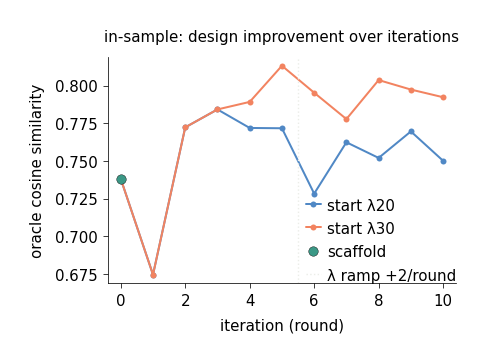

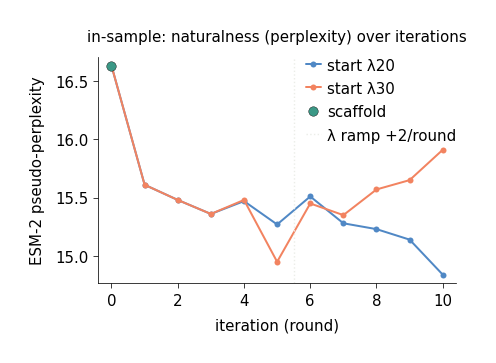

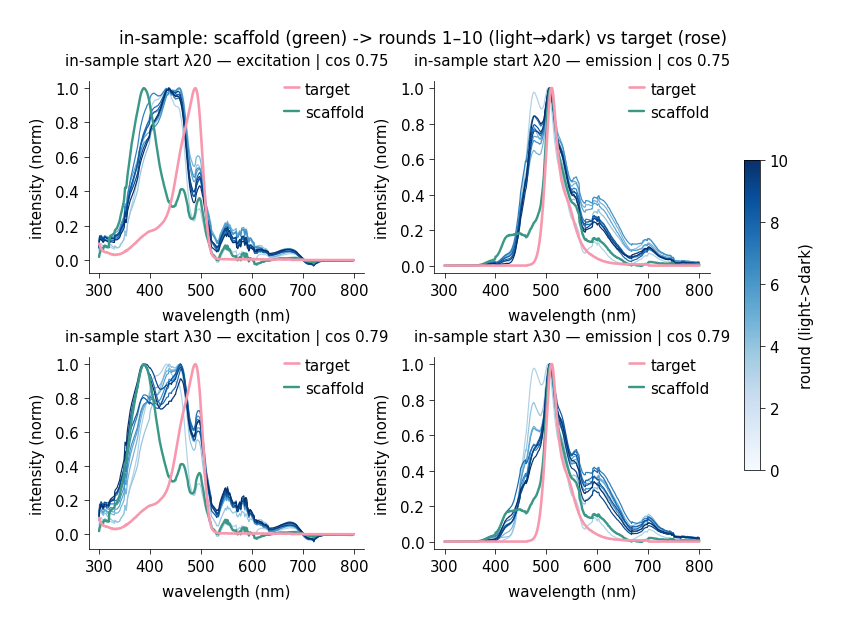

In [7]:
import matplotlib as mpl
GROUP="in-sample"
hist=list(csv.DictReader(open(hist_path)))
hg=[h for h in hist if h["label"]==GROUP]
lams=sorted(set(int(h["lam"]) for h in hg)); maxr=max(int(h["round"]) for h in hg)
ti=int(hg[0]["target_idx"]); si=int(hg[0]["scaffold_idx"]); tgt=Y[ti]
SCAF=apc.seaweed                                                   # scaffold (round 0) drawn in contrasting green
ramp=[int(h["round"]) for h in hg if int(h["lam_used"])!=int(h["lam"])]; ramp_start=min(ramp) if ramp else None
print(f"{GROUP}: scaffold {rows[si]['name']} (em{EMM[si]:.0f}) -> target {rows[ti]['name']} (em{EMM[ti]:.0f}) | start-lambdas {lams} | rounds 0..{maxr}")
def _curve(metric, ylabel, title):
    fig,a=plt.subplots(figsize=(6,4.3),constrained_layout=True)
    for lam in lams:
        hh=sorted([h for h in hg if int(h["lam"])==lam],key=lambda h:int(h["round"]))
        a.plot([int(h["round"]) for h in hh],[float(h[metric]) for h in hh],marker="o",label=f"start \u03bb{lam}")
    v0=float([h for h in hg if int(h["round"])==0][0][metric])
    a.scatter([0],[v0],color=SCAF,s=90,zorder=5,edgecolor="k",linewidth=0.4,label="scaffold")
    if ramp_start is not None: a.axvline(ramp_start-0.5,ls=":",color=apc.gray,lw=1.4,label=f"\u03bb ramp +{2}/round")
    a.set_xlabel("iteration (round)"); a.set_ylabel(ylabel); a.set_title(title); a.legend(); plt.show()
if HAVE_PLT and hg:
    _curve("cos","oracle cosine similarity",f"{GROUP}: design improvement over iterations")
    _curve("ppl","ESM-2 pseudo-perplexity",f"{GROUP}: naturalness (perplexity) over iterations")

    cmap=mpl.colormaps["Blues"]; cround=lambda r: cmap(0.25+0.75*r/maxr)
    halves=[("excitation",slice(0,G)),("emission",slice(G,None))]
    fig,axes=plt.subplots(len(lams),2,figsize=(11,4.0*len(lams)),squeeze=False,constrained_layout=True)
    for ri,lam in enumerate(lams):
        hh=sorted([h for h in hg if int(h["lam"])==lam],key=lambda h:int(h["round"]))
        for ci,(hname,sl) in enumerate(halves):
            a=axes[ri,ci]
            a.plot(grid,tgt[sl],color=apc.rose,lw=2.6,zorder=4,label="target")
            for h in hh:
                r=int(h["round"]); spec=oracle_spectrum(h["designed_seq"])[0].cpu().numpy()
                if r==0: a.plot(grid,spec[sl],color=SCAF,lw=2.4,zorder=3,label="scaffold")
                else:    a.plot(grid,spec[sl],color=cround(r),lw=1.2)
            a.set_title(f"{GROUP} start \u03bb{lam} \u2014 {hname} | cos {float(hh[-1]['cos']):.2f}")
            a.set_xlabel("wavelength (nm)"); a.set_ylabel("intensity (norm)"); a.legend()
    sm=mpl.cm.ScalarMappable(cmap=cmap,norm=mpl.colors.Normalize(0,maxr)); sm.set_array([])
    fig.colorbar(sm,ax=axes,label="round (light->dark)",fraction=0.025)
    fig.suptitle(f"{GROUP}: scaffold (green) -> rounds 1\u2013{maxr} (light\u2192dark) vs target (rose)")
    plt.show()

OOD: scaffold SCFP3A (em474) -> target DarkVenus (em525) | start-lambdas [20, 30] | rounds 0..10


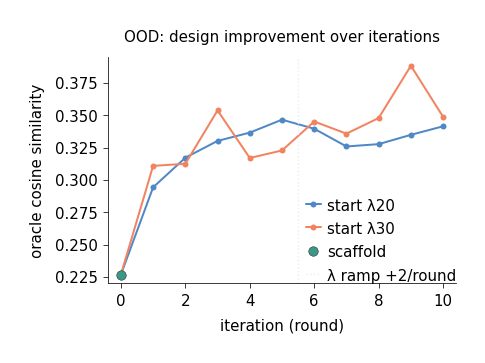

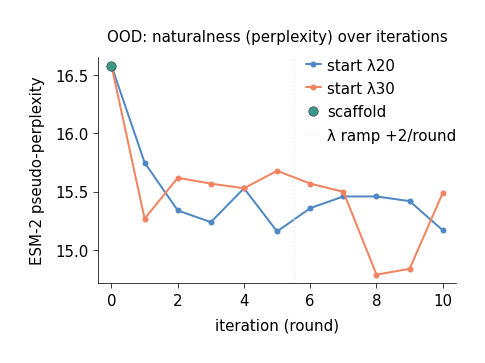

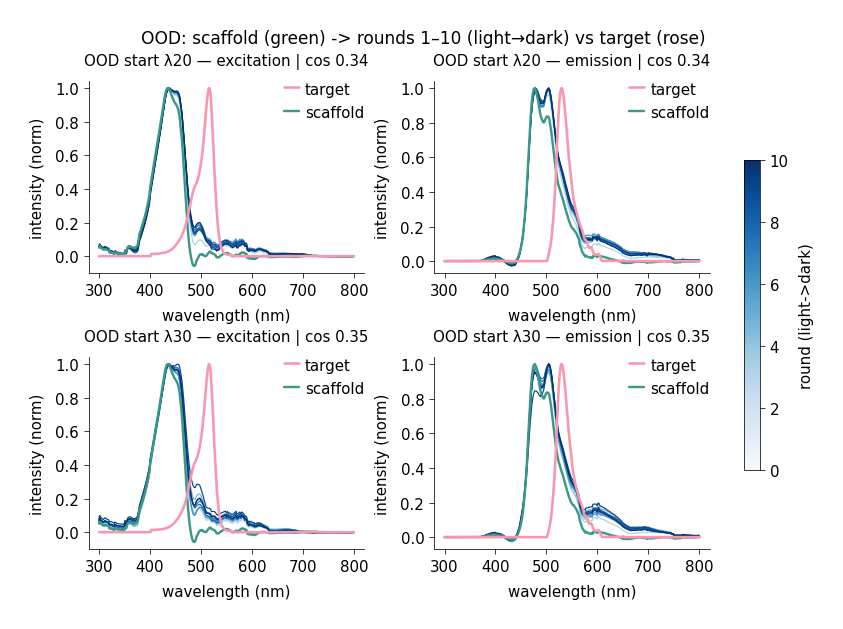

In [8]:
import matplotlib as mpl
GROUP="OOD"
hist=list(csv.DictReader(open(hist_path)))
hg=[h for h in hist if h["label"]==GROUP]
lams=sorted(set(int(h["lam"]) for h in hg)); maxr=max(int(h["round"]) for h in hg)
ti=int(hg[0]["target_idx"]); si=int(hg[0]["scaffold_idx"]); tgt=Y[ti]
SCAF=apc.seaweed                                                   # scaffold (round 0) drawn in contrasting green
ramp=[int(h["round"]) for h in hg if int(h["lam_used"])!=int(h["lam"])]; ramp_start=min(ramp) if ramp else None
print(f"{GROUP}: scaffold {rows[si]['name']} (em{EMM[si]:.0f}) -> target {rows[ti]['name']} (em{EMM[ti]:.0f}) | start-lambdas {lams} | rounds 0..{maxr}")
def _curve(metric, ylabel, title):
    fig,a=plt.subplots(figsize=(6,4.3),constrained_layout=True)
    for lam in lams:
        hh=sorted([h for h in hg if int(h["lam"])==lam],key=lambda h:int(h["round"]))
        a.plot([int(h["round"]) for h in hh],[float(h[metric]) for h in hh],marker="o",label=f"start \u03bb{lam}")
    v0=float([h for h in hg if int(h["round"])==0][0][metric])
    a.scatter([0],[v0],color=SCAF,s=90,zorder=5,edgecolor="k",linewidth=0.4,label="scaffold")
    if ramp_start is not None: a.axvline(ramp_start-0.5,ls=":",color=apc.gray,lw=1.4,label=f"\u03bb ramp +{2}/round")
    a.set_xlabel("iteration (round)"); a.set_ylabel(ylabel); a.set_title(title); a.legend(); plt.show()
if HAVE_PLT and hg:
    _curve("cos","oracle cosine similarity",f"{GROUP}: design improvement over iterations")
    _curve("ppl","ESM-2 pseudo-perplexity",f"{GROUP}: naturalness (perplexity) over iterations")

    cmap=mpl.colormaps["Blues"]; cround=lambda r: cmap(0.25+0.75*r/maxr)
    halves=[("excitation",slice(0,G)),("emission",slice(G,None))]
    fig,axes=plt.subplots(len(lams),2,figsize=(11,4.0*len(lams)),squeeze=False,constrained_layout=True)
    for ri,lam in enumerate(lams):
        hh=sorted([h for h in hg if int(h["lam"])==lam],key=lambda h:int(h["round"]))
        for ci,(hname,sl) in enumerate(halves):
            a=axes[ri,ci]
            a.plot(grid,tgt[sl],color=apc.rose,lw=2.6,zorder=4,label="target")
            for h in hh:
                r=int(h["round"]); spec=oracle_spectrum(h["designed_seq"])[0].cpu().numpy()
                if r==0: a.plot(grid,spec[sl],color=SCAF,lw=2.4,zorder=3,label="scaffold")
                else:    a.plot(grid,spec[sl],color=cround(r),lw=1.2)
            a.set_title(f"{GROUP} start \u03bb{lam} \u2014 {hname} | cos {float(hh[-1]['cos']):.2f}")
            a.set_xlabel("wavelength (nm)"); a.set_ylabel("intensity (norm)"); a.legend()
    sm=mpl.cm.ScalarMappable(cmap=cmap,norm=mpl.colors.Normalize(0,maxr)); sm.set_array([])
    fig.colorbar(sm,ax=axes,label="round (light->dark)",fraction=0.025)
    fig.suptitle(f"{GROUP}: scaffold (green) -> rounds 1\u2013{maxr} (light\u2192dark) vs target (rose)")
    plt.show()

## 6. Per-design alignments (orig, design, target)

For each design, its **three** sequences are aligned together on their own — scaffold (orig), design, and
target — with **biotite** (BLOSUM62), colored by residue type and cropped to that design's edited region.
The scaffold is repeated in every triplet, so each design sits directly between the sequence it started from
and the sequence it targets (and each design aligns to *its own* target rather than to a shared MSA).

4 per-design triplet alignments (orig, design, target)


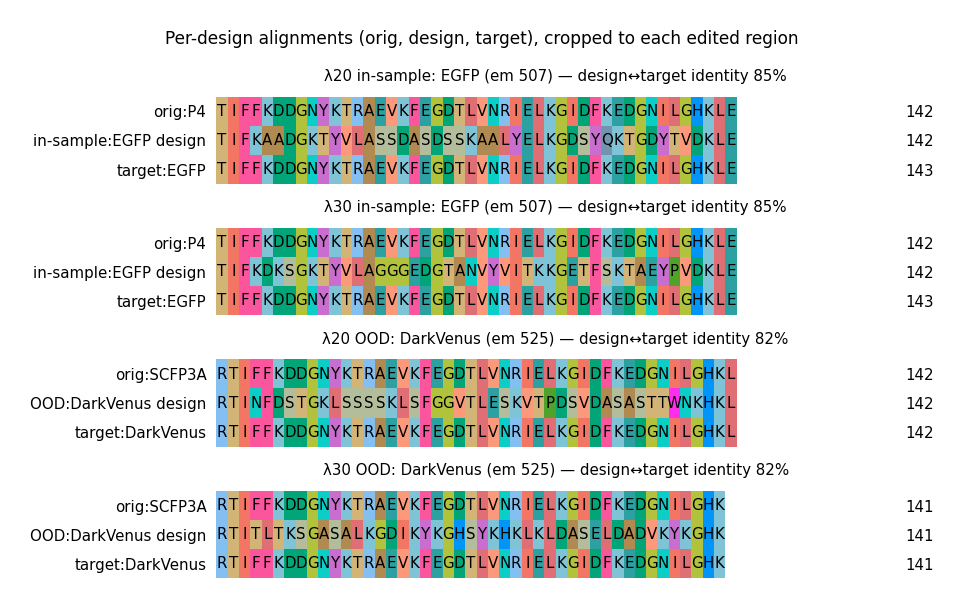

In [9]:
import biotite.sequence as bseq, biotite.sequence.align as balign, biotite.sequence.graphics as bgraphics
recs=list(csv.DictReader(open(os.path.join("fp_designs","designs.csv"))))
MAT=balign.SubstitutionMatrix.std_protein_matrix(); MARGIN=3; SPL=60

def triplet_aln(d):
    """Align (orig, design, target) for one design; crop to columns where the design edits the scaffold."""
    raw=[d["scaffold_seq"], d["designed_seq"], d["target_seq"]]
    labels=[f"orig:{d['scaffold']}", f"{d['role']}:{d['target_name']} design", f"target:{d['target_name']}"]
    aln,_,_,_=balign.align_multiple([bseq.ProteinSequence(s) for s in raw], MAT, gap_penalty=(-10,-1))
    tr=aln.trace
    sym=lambda k,c:(raw[k][tr[c,k]] if tr[c,k]>=0 else "-")
    both=[c for c in range(tr.shape[0]) if tr[c,1]>=0 and tr[c,2]>=0]               # design & target both aligned
    id_dt=(sum(sym(1,c)==sym(2,c) for c in both)/len(both)) if both else 0.0        # design<->target identity
    diff=[c for c in range(tr.shape[0]) if sym(0,c)!=sym(1,c)]                      # design vs scaffold
    lo,hi=(max(0,min(diff)-MARGIN), min(tr.shape[0],max(diff)+MARGIN+1)) if diff else (0,tr.shape[0])
    return aln[lo:hi], labels, id_dt

print(f"{len(recs)} per-design triplet alignments (orig, design, target)")
if HAVE_PLT and recs:
    n=len(recs); fig,axes=plt.subplots(n,1,figsize=(13, 2*n)); axes=np.atleast_1d(axes)
    for r,d in enumerate(recs):
        sub,labels,id_dt=triplet_aln(d)
        bgraphics.plot_alignment_type_based(axes[r], sub, labels=labels, symbols_per_line=SPL, show_numbers=True)
        axes[r].set_title(f"\u03bb{d['lam']} {d['role']}: {d['target_name']} (em {d['target_em']}) — design↔target identity {id_dt:.0%}")
    plt.suptitle("Per-design alignments (orig, design, target), cropped to each edited region")
    plt.tight_layout(); plt.show()

## 7. ESM-2 embedding space (scaffold vs designs vs targets)

Per-sequence ESM-2 (layer 33) embeddings — **mean-pooled** over residues — for the scaffold, each generated
design, and each target, projected to 2D with **PCA**. Grey lines link each design to its target. This shows
whether a design moves through embedding space *toward* its target, and whether OOD targets sit far from the
scaffold/training manifold (a visual companion to the oracle-trust / OOD discussion).

embedded 10 seqs (1280-d mean-pool) -> PCA 2D (EVR 0.85)


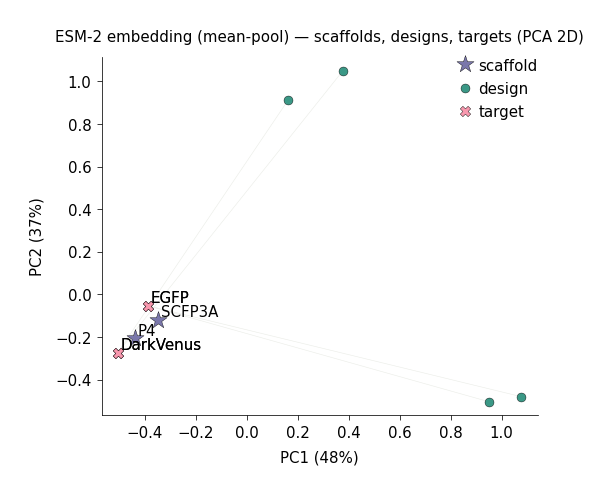

In [10]:
from sklearn.decomposition import PCA as _PCA
recs=list(csv.DictReader(open(os.path.join("fp_designs","designs.csv"))))
emb_items=[]; _seen=set()
for d in recs:                                                 # unique scaffolds first
    if d["scaffold_idx"] not in _seen:
        _seen.add(d["scaffold_idx"]); emb_items.append((d["scaffold"], d["scaffold_seq"], "scaffold"))
for d in recs:
    emb_items.append((f"{d['role']} \u03bb{d['lam']}", d["designed_seq"], "design"))
    emb_items.append((d["target_name"], d["target_seq"], "target"))
H,mask=fpm.resid_embed([s for _,s,_ in emb_items], dev)        # (B,Lmax,1280) layer-33 per-residue
vec=fpm.masked_pool(H, mask, "mean").cpu().numpy()             # mean-pool over residues -> (B,1280)
pca2=_PCA(2, random_state=0); emb2=pca2.fit_transform(vec); evr=pca2.explained_variance_ratio_
kinds=np.array([k for *_,k in emb_items])
print(f"embedded {len(emb_items)} seqs (1280-d mean-pool) -> PCA 2D (EVR {evr.sum():.2f})")
if HAVE_PLT:
    plt.figure(figsize=(7.5,6.5))
    di=len(_seen)                                              # designs/targets interleaved after the scaffolds
    while di < len(emb_items)-1:
        plt.plot(emb2[[di,di+1],0], emb2[[di,di+1],1], color=apc.gray, lw=0.6, zorder=1); di+=2
    style={"scaffold":(apc.aster,"*",320), "design":(apc.seaweed,"o",80), "target":(apc.rose,"X",110)}
    for kind,(col,mk,sz) in style.items():
        sel=np.where(kinds==kind)[0]
        plt.scatter(emb2[sel,0], emb2[sel,1], color=col, marker=mk, s=sz, label=kind, edgecolor="k", linewidth=0.4, zorder=2)
    for j,(name,seq,kind) in enumerate(emb_items):
        if kind!="design":
            plt.annotate(name[:12], (emb2[j,0],emb2[j,1]), xytext=(3,3), textcoords="offset points")
    plt.xlabel(f"PC1 ({evr[0]:.0%})"); plt.ylabel(f"PC2 ({evr[1]:.0%})")
    plt.title("ESM-2 embedding (mean-pool) — scaffolds, designs, targets (PCA 2D)")
    plt.legend(); plt.tight_layout(); plt.show()

## Notes
- Models from `surrogate_model_design_dual.ipynb` (both **cnn-max**, cosine-trained); they output PCA coefficients
  reconstructed and peak-normalized via the saved `dual_{surrogate,oracle}_pca.joblib` bases.
- Guidance and oracle judgment both use **cosine similarity** (per-half ex|em, higher = better). Candidate scoring
  is `z(logp) + λ·z(cosine)`, so larger **λ** weights spectral match over ESM naturalness — compare λ=5 vs λ=15 on
  oracle cosine and pseudo-perplexity (spectral gain vs naturalness cost).
- The surrogate guides; the oracle (trained on the other split) judges. Surrogate and oracle now share the same
  architecture, so the oracle is a less independent check than a cross-family evaluator. Keep designs on-manifold
  (low pseudo-perplexity); target chromophore-region positions for bigger, realistic shifts.